In [ ]:
import pandas as pandas
import numpy as numpy
import matplotlib.pyplot as plt 
import seaborn as sns


Set up success


In [3]:
import pandas as pd

trader = pd.read_csv("../data/historical_data.csv")
fear = pd.read_csv("../data/fear_greed_index.csv")

print("Trader Data")
display(trader.head())

print("Fear & Greed Data")
display(fear.head())

Trader Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Fear & Greed Data


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
print("Trader Data Shape:", trader.shape)
print("Fear & Greed Shape:", fear.shape)

print("\nTrader Columns:")
print(trader.columns)

print("\nFear & Greed Columns:")
print(fear.columns)

Trader Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)

Trader Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [6]:
#check data types
print("Trader Data Info")
trader.info()

print("\nFear & Greed Info")
fear.info()

Trader Data Info
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), fl

In [7]:
#check missing value
print("Missing Values in Trader Data")
print(trader.isnull().sum())

print("\nMissing Values in Fear & Greed Data")
print(fear.isnull().sum())

Missing Values in Trader Data
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing Values in Fear & Greed Data
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [9]:
#Duplicate
print("Trader Duplicates:", trader.duplicated().sum())
print("Fear & Greed Duplicates:", fear.duplicated().sum())

Trader Duplicates: 0
Fear & Greed Duplicates: 0


In [10]:
# Convert trader timestamp to datetime
trader["Timestamp IST"] = pd.to_datetime(
    trader["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

trader["date"] = trader["Timestamp IST"].dt.date


fear["date"] = pd.to_datetime(fear["date"]).dt.date

print("Date conversion completed successfully!")

Date conversion completed successfully!


In [11]:
merged_data = pd.merge(
    trader,
    fear,
    on="date",
    how="left"
)

print("Merged Shape:", merged_data.shape)

merged_data.head()

Merged Shape: (211224, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [12]:
print(merged_data[["Timestamp IST", "classification", "value"]].head())

        Timestamp IST classification  value
0 2024-12-02 22:50:00  Extreme Greed   80.0
1 2024-12-02 22:50:00  Extreme Greed   80.0
2 2024-12-02 22:50:00  Extreme Greed   80.0
3 2024-12-02 22:50:00  Extreme Greed   80.0
4 2024-12-02 22:50:00  Extreme Greed   80.0


In [13]:
# Average Closed  by sentiment

sentiment_analysis = merged_data.groupby("classification")["Closed PnL"].agg(
    ["count", "mean", "median", "max", "min"]
)

print(sentiment_analysis)

                count       mean  median           max           min
classification                                                      
Extreme Fear    21400  34.537862     0.0  115287.00000  -31036.69194
Extreme Greed   39992  67.892861     0.0   44223.45187  -10259.46800
Fear            61837  54.290400     0.0  135329.09010  -35681.74723
Greed           50303  42.743559     0.0   74530.52371 -117990.10410
Neutral         37686  34.307718     0.0   48504.09555  -24500.00000


In [14]:
profit = merged_data.groupby("classification")["Closed PnL"].sum()

print(profit)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [15]:
trade_side = pd.crosstab(
    merged_data["classification"],
    merged_data["Side"]
)

print(trade_side)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


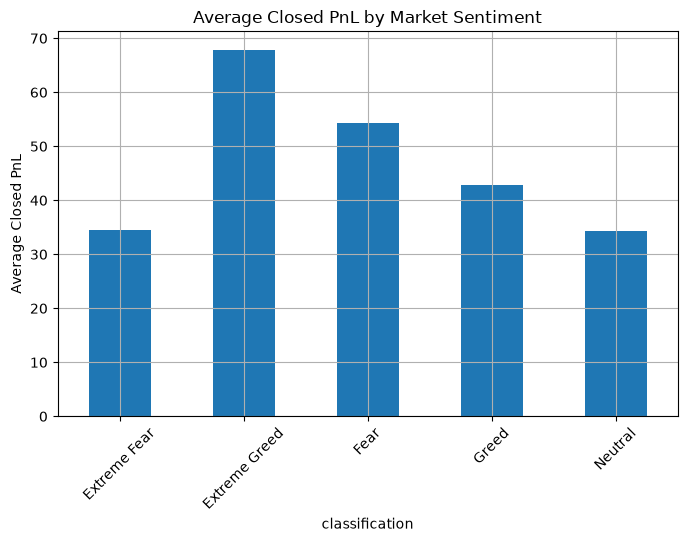

In [16]:

merged_data.groupby("classification")["Closed PnL"].mean().plot(
    kind="bar",
    figsize=(8,5),
    title="Average Closed PnL by Market Sentiment"
)

plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

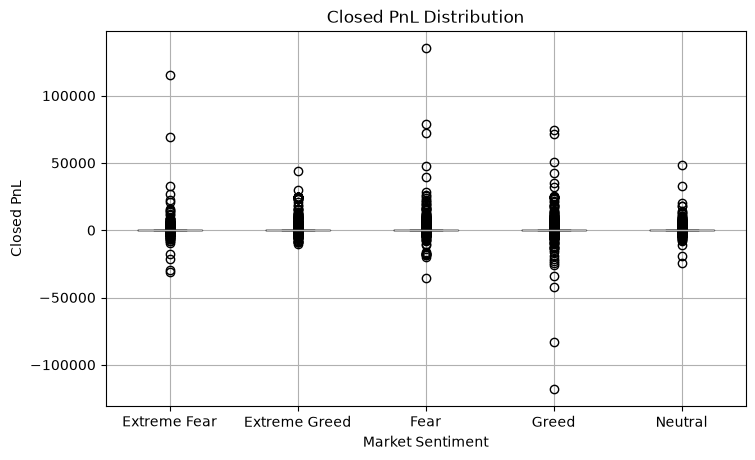

In [17]:

merged_data.boxplot(
    column="Closed PnL",
    by="classification",
    figsize=(8,5)
)

plt.title("Closed PnL Distribution")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()